# Forecasting Pipeline and Feature Engineering Plan

## Objective
This project aims to forecast **daily Revenue** and **daily COGS** for the period **2023-01-01 to 2024-07-01** using historical sales data from **2012-07-04 to 2022-12-31**. The primary goal is to build a robust, competition-ready forecasting pipeline that maximizes leaderboard performance under the evaluation metrics **MAE**, **RMSE**, and **R²**.

## Modeling Principle
The strategy is designed for **tree-based boosting models** such as **LightGBM**, **XGBoost**, and **CatBoost**. For this type of problem, the most effective approach is to combine:

- reliable date-derived signals,
- Vietnamese holiday and lunar-calendar effects,
- cyclical encodings,
- interaction features,
- and carefully selected seasonality proxies.

The plan is intentionally conservative at the start and becomes more expressive only after validation proves that each additional feature group improves generalization.

## Overall Pipeline

### 1. Data Preparation
- Parse `Date` as a true datetime column.
- Sort all records chronologically.
- Check for missing dates, duplicates, and obvious anomalies.
- Confirm that Revenue and COGS are aligned at the same daily granularity.

### 2. Calendar Feature Engineering
Extract time-based variables from `Date` to capture weekly, monthly, quarterly, and annual seasonality. These features provide the model with information about regular demand cycles and end-of-period effects.

### 3. Vietnamese Holiday and Lunar Features
Create indicators for major Vietnamese holidays and spending periods such as:
- Tết Nguyên Đán and surrounding windows,
- 30/4 - 1/5,
- 2/9,
- Christmas,
- Tết Trung Thu,
- Giỗ Tổ Hùng Vương,
- Vu Lan,
- Tết Đoan Ngọ,
- and back-to-school season.

For each event, use not only a binary holiday flag but also **days before**, **days after**, and **holiday window** features to capture pre-event buildup and post-event normalization.

### 4. Cyclical Encoding
Represent periodic variables using cyclical transformations such as sine and cosine encodings for:
- day of week,
- week of year,
- month,
- and day of year.

This helps the model understand that time is circular, not linear.

### 5. Seasonality Proxy Features
Add engineered signals that approximate repeating demand structure, including:
- month start / end,
- quarter start / end,
- year start / end,
- week of month,
- weekend flags,
- payday-related windows,
- and seasonal boundary indicators.

These features help the model capture business-cycle behavior that tends to repeat across years.

### 6. Interaction Features
Generate a small set of carefully chosen interactions, such as:
- weekday × month,
- weekday × holiday,
- weekend × holiday,
- month × holiday window,
- quarter × weekday,
- and lunar event × weekday.

Interactions are useful when the effect of one calendar feature depends on another. They should be added selectively to reduce overfitting risk.

### 7. Target Modeling Strategy
Revenue and COGS are related but not identical. The best practical setup is to:
- use a shared core feature set,
- allow target-specific transformations where justified,
- and evaluate the two targets jointly while keeping the modeling pipeline simple and stable.

## Feature Priority

### Tier 1: Essential
These are the most important and lowest-risk features:
- day of week,
- month,
- day of year,
- week of year,
- weekend flag,
- month end / start,
- quarter end / start,
- year end / start,
- major holiday flags,
- Tết distance features,
- cyclical encodings for core calendar variables.

### Tier 2: Useful
These often improve performance but should be validated carefully:
- week of month,
- payday window,
- pre-holiday and post-holiday windows,
- lunar holiday proximity features,
- seasonal boundary indicators,
- selected interaction terms.

### Tier 3: Optional
These may provide small gains but carry higher risk of noise or overfitting:
- Fourier terms,
- more complex calendar interactions,
- narrow event windows for less important holidays,
- highly specific business-cycle assumptions.

## Validation Strategy
The feature set should not be accepted based on intuition alone. Each block of features must be tested using time-aware validation.

Recommended process:
1. Build a clean baseline with core date features.
2. Add holiday and lunar features.
3. Add cyclical encodings.
4. Add interaction features only if they improve validation consistently.
5. Compare models on multiple time-based folds instead of a single split.

## Risk Management
The main risks in this forecasting task are:
- overfitting to rare holiday windows,
- noisy lunar-calendar assumptions,
- redundant cyclical features,
- and overly complex interactions that do not generalize.

To control these risks, prefer features that are stable across years and easy for tree models to learn. Keep the first version of the pipeline compact, then expand only when cross-validation proves that a feature group is useful.

## Expected Outcome
The final pipeline should produce a compact but expressive feature matrix that captures:
- regular calendar seasonality,
- Vietnamese holiday behavior,
- lunar-calendar shifts,
- and short-term business-cycle patterns.

This approach is designed to give the models enough structure to learn from while preserving strong out-of-sample generalization.


# VinUni Datathon Forecasting Pipeline

This notebook builds a competition-ready daily forecasting pipeline for Revenue and COGS.

The objective is to predict the full future horizon using historical sales data, with feature engineering focused on:
- calendar seasonality,
- Vietnamese holiday and lunar effects,
- cyclical time patterns,
- interaction features,
- and conservative validation-driven feature selection.

The pipeline is designed for tree-based models such as LightGBM, XGBoost, and CatBoost.

In [61]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
import xgboost as xgb


CURRENT_PATH = Path.cwd()
ROOT_DIR = CURRENT_PATH.parent
DATA_DIR = ROOT_DIR / "data"
TRAIN_PATH = DATA_DIR / 'raw' /"sales.csv"
# SUBMISSION_PATH = DATA_DIR / 'raw' /"sample_submission.csv"

SUBMISSION_PATH = ROOT_DIR / 'outputs' / 'submission test' / "sample_submission_test.csv"

RANDOM_STATE = 42
N_SPLITS = 5
print(f"Root directory: {ROOT_DIR}")

Root directory: d:\University\Semester 8\Class - Data visualization\Project\Final\Fashion-E-commerce-Dashboard


In [ ]:
import pandas as pd
from datetime import datetime
import os
def create_sample_submission(start_date, end_date, output_file="../outputs/sample_submission_test.csv"):
    dates = pd.date_range(start=start_date, end=end_date, freq='D')

    # Tạo DataFrame
    df = pd.DataFrame({
        "Date": dates.strftime("%Y-%m-%d")
    })

    df.to_csv(output_file, index=False)

    print(f"Đã tạo file: {output_file}")

def get_today():
    return datetime.today().strftime("%Y-%m-%d")


SUBMISSION = ROOT_DIR / "outputs" / "submission test" / "sample_submission_test.csv"

if not SUBMISSION.exists():
    # Tạo folder nếu chưa tồn tại
    folder_path = os.path.dirname(SUBMISSION)
    os.makedirs(folder_path, exist_ok=True)

create_sample_submission(
    start_date="2023-01-01",
    end_date=get_today(),
    output_file=SUBMISSION
)

Đã tạo file: d:\University\Semester 8\Class - Data visualization\Project\Final\Fashion-E-commerce-Dashboard\outputs\submission test\sample_submission_test.csv


## 1. Data Loading and Schema Check

We load the historical training data from `sales.csv` and use `sample_submission.csv` only as a submission template.

Important note:
`sample_submission.csv` is not the real test feature table. It is only a template that provides the required forecast dates and final output schema.

In [62]:
train_df = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
submission_template = pd.read_csv(SUBMISSION_PATH, parse_dates=["Date"])

train_df = train_df.sort_values("Date").reset_index(drop=True)
submission_template = submission_template.sort_values("Date").reset_index(drop=True)

forecast_df = submission_template[["Date"]].copy()

print(f"Root directory: {ROOT_DIR}")
print(f"Data directory: {DATA_DIR}")
print(train_df.head())
print(submission_template.head())
print(train_df.shape, submission_template.shape)

Root directory: d:\University\Semester 8\Class - Data visualization\Project\Final\Fashion-E-commerce-Dashboard
Data directory: d:\University\Semester 8\Class - Data visualization\Project\Final\Fashion-E-commerce-Dashboard\data
        Date     Revenue        COGS
0 2012-07-04  5123547.94  3982991.19
1 2012-07-05  2751773.45  2150580.23
2 2012-07-06  3054029.42  2517632.84
3 2012-07-07  2667930.94  2108246.62
4 2012-07-08  2360851.90  1808622.79
        Date
0 2023-01-01
1 2023-01-02
2 2023-01-03
3 2023-01-04
4 2023-01-05
(3833, 3) (1228, 1)


In [63]:
def basic_checks(df, name):
    print(f"--- {name} ---")
    print("Date range:", df["Date"].min(), "to", df["Date"].max())
    print("Missing values:\n", df.isna().sum())
    print("Duplicate dates:", df["Date"].duplicated().sum())
    print()

basic_checks(train_df, "Train")
basic_checks(submission_template, "Submission Template")

--- Train ---
Date range: 2012-07-04 00:00:00 to 2022-12-31 00:00:00
Missing values:
 Date       0
Revenue    0
COGS       0
dtype: int64
Duplicate dates: 0

--- Submission Template ---
Date range: 2023-01-01 00:00:00 to 2026-05-12 00:00:00
Missing values:
 Date    0
dtype: int64
Duplicate dates: 0



## 2. Feature Engineering Strategy

The feature set is built in layers:
1. core calendar variables,
2. Vietnamese holiday and lunar proxy features,
3. cyclical encodings,
4. seasonality boundary indicators,
5. interaction features.

The goal is to start with stable, low-risk features and only add more complex signals if they improve validation performance.

In [64]:
def add_calendar_features(df):
    df = df.copy()
    dt = df["Date"]

    df["year"] = dt.dt.year
    df["month"] = dt.dt.month
    df["day"] = dt.dt.day
    df["dayofweek"] = dt.dt.dayofweek
    df["dayofyear"] = dt.dt.dayofyear
    df["weekofyear"] = dt.dt.isocalendar().week.astype(int)
    df["quarter"] = dt.dt.quarter

    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_month_start"] = dt.dt.is_month_start.astype(int)
    df["is_month_end"] = dt.dt.is_month_end.astype(int)
    df["is_quarter_start"] = dt.dt.is_quarter_start.astype(int)
    df["is_quarter_end"] = dt.dt.is_quarter_end.astype(int)
    df["is_year_start"] = dt.dt.is_year_start.astype(int)
    df["is_year_end"] = dt.dt.is_year_end.astype(int)

    df["week_of_month"] = ((df["day"] - 1) // 7) + 1
    df["days_in_month"] = dt.dt.days_in_month
    df["days_to_month_end"] = df["days_in_month"] - df["day"]
    df["days_from_month_start"] = df["day"] - 1

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    return df

In [65]:
def add_event_features(df):
    df = df.copy()

    df["is_new_year"] = ((df["month"] == 1) & (df["day"] == 1)).astype(int)
    df["is_304"] = ((df["month"] == 4) & (df["day"] == 30)).astype(int)
    df["is_51"] = ((df["month"] == 5) & (df["day"] == 1)).astype(int)
    df["is_29"] = ((df["month"] == 9) & (df["day"] == 2)).astype(int)
    df["is_christmas"] = ((df["month"] == 12) & (df["day"] == 25)).astype(int)

    df["is_year_end_window"] = ((df["month"] == 12) & (df["day"] >= 20)).astype(int)
    df["is_year_start_window"] = ((df["month"] == 1) & (df["day"] <= 7)).astype(int)
    df["is_back_to_school"] = ((df["month"] == 8) | ((df["month"] == 9) & (df["day"] <= 10))).astype(int)
    df["is_payday_window"] = df["day"].isin([1, 2, 3, 10, 11, 12, 15, 16, 17, 28, 29, 30, 31]).astype(int)

    return df

In [66]:
def add_lunar_proxy_features(df):
    df = df.copy()

    df["pre_tet_window"] = (((df["month"] == 1) & (df["day"] >= 15)) | ((df["month"] == 2) & (df["day"] <= 15))).astype(int)
    df["post_tet_window"] = (((df["month"] == 2) & (df["day"] >= 16)) | ((df["month"] == 3) & (df["day"] <= 10))).astype(int)
    df["tet_season"] = ((df["month"] == 1) | (df["month"] == 2)).astype(int)

    return df

In [67]:
def add_interaction_features(df):
    df = df.copy()

    df["weekday_x_month"] = df["dayofweek"] * 12 + df["month"]
    df["weekday_x_weekend"] = df["dayofweek"] * df["is_weekend"]
    df["month_x_year_end"] = df["month"] * df["is_year_end"]
    df["holiday_x_weekend"] = df["is_weekend"] * (
        df["is_new_year"] + df["is_304"] + df["is_51"] + df["is_29"] + df["is_christmas"]
    )
    df["tet_x_weekday"] = df["tet_season"] * df["dayofweek"]
    df["payday_x_month"] = df["is_payday_window"] * df["month"]

    return df

In [68]:
def build_features(df):
    df = df.copy()
    df = add_calendar_features(df)
    df = add_event_features(df)
    df = add_lunar_proxy_features(df)
    df = add_interaction_features(df)
    return df

train_feat = build_features(train_df)
forecast_feat = build_features(forecast_df)

train_feat.head()

,Date,Revenue,COGS,year,month,day,dayofweek,dayofyear,weekofyear,quarter,...,is_payday_window,pre_tet_window,post_tet_window,tet_season,weekday_x_month,weekday_x_weekend,month_x_year_end,holiday_x_weekend,tet_x_weekday,payday_x_month
0,2012-07-04,5123547.94,3982991.19,2012,7,4,2,186,27,3,...,0,0,0,0,31,0,0,0,0,0
1,2012-07-05,2751773.45,2150580.23,2012,7,5,3,187,27,3,...,0,0,0,0,43,0,0,0,0,0
2,2012-07-06,3054029.42,2517632.84,2012,7,6,4,188,27,3,...,0,0,0,0,55,0,0,0,0,0
3,2012-07-07,2667930.94,2108246.62,2012,7,7,5,189,27,3,...,0,0,0,0,67,5,0,0,0,0
4,2012-07-08,2360851.90,1808622.79,2012,7,8,6,190,27,3,...,0,0,0,0,79,6,0,0,0,0


## 3. Feature Set Definition

The feature matrix uses only date-derived variables, because the competition forecast horizon is future data.

The shared feature set is used for both Revenue and COGS, since the two targets are strongly related and should benefit from the same seasonal structure.

In [69]:
target_cols = ["Revenue", "COGS"]

feature_cols = [
    "year", "month", "day", "dayofweek", "dayofyear", "weekofyear", "quarter",
    "is_weekend", "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end",
    "is_year_start", "is_year_end", "week_of_month", "days_in_month",
    "days_to_month_end", "days_from_month_start",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",
    "is_new_year", "is_304", "is_51", "is_29", "is_christmas",
    "is_year_end_window", "is_year_start_window", "is_back_to_school",
    "is_payday_window", "pre_tet_window", "post_tet_window", "tet_season",
    "weekday_x_month", "weekday_x_weekend", "month_x_year_end",
    "holiday_x_weekend", "tet_x_weekday", "payday_x_month",
]

X_train = train_feat[feature_cols]
y_revenue = train_feat["Revenue"]
y_cogs = train_feat["COGS"]

X_forecast = forecast_feat[feature_cols]

## 4. Time-Aware Validation

We use time-series validation rather than random splitting.

This is essential because the forecasting problem is temporal and the model must generalize to future dates.

In [70]:
def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [71]:
def train_lgbm(X, y):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    oof = np.zeros(len(X))
    models = []

    params = {
        "objective": "regression",
        "learning_rate": 0.03,
        "n_estimators": 5000,
        "num_leaves": 31,
        "min_data_in_leaf": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    }

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(200, verbose=False)],
        )

        pred = model.predict(X_val)
        oof[valid_idx] = pred
        models.append(model)

        mae, rmse, r2 = evaluate_predictions(y_val, pred)
        print(f"Fold {fold}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

    print("OOF:", evaluate_predictions(y, oof))
    return models, oof

In [72]:
revenue_models, revenue_oof = train_lgbm(X_train, y_revenue)
cogs_models, cogs_oof = train_lgbm(X_train, y_cogs)

Fold 1: MAE=1049110.0616, RMSE=1463986.7752, R2=0.7036
Fold 2: MAE=1121328.1556, RMSE=1603969.5937, R2=0.7402
Fold 3: MAE=1468521.9410, RMSE=1840234.5699, R2=0.5424
Fold 4: MAE=914426.5210, RMSE=1142798.2135, R2=0.4476
Fold 5: MAE=579065.1988, RMSE=760780.2068, R2=0.7827
OOF: (1593726.2370246253, np.float64(2385346.6708835703), 0.17394190205338167)
Fold 1: MAE=866097.0734, RMSE=1175130.8466, R2=0.7232
Fold 2: MAE=902224.7561, RMSE=1263558.8837, R2=0.7741
Fold 3: MAE=1234872.3222, RMSE=1522250.7329, R2=0.5375
Fold 4: MAE=638007.6625, RMSE=798611.5291, R2=0.6588
Fold 5: MAE=489692.0851, RMSE=651993.2337, R2=0.7832
OOF: (1318709.690679, np.float64(2007435.3087866993), 0.18196264301645593)


In [73]:
def inspect_time_folds(X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        print(f"Fold {fold}")
        print("Train date range:", train_df.loc[train_idx, "Date"].min(), "to", train_df.loc[train_idx, "Date"].max())
        print("Valid date range:", train_df.loc[valid_idx, "Date"].min(), "to", train_df.loc[valid_idx, "Date"].max())
        print("Train size:", len(train_idx), "Valid size:", len(valid_idx))
        print("Train target mean/std:", round(y_tr.mean(), 2), round(y_tr.std(), 2))
        print("Valid target mean/std:", round(y_val.mean(), 2), round(y_val.std(), 2))
        print("-" * 80)

inspect_time_folds(X_train, y_revenue, n_splits=N_SPLITS)

Fold 1
Train date range: 2012-07-04 00:00:00 to 2014-04-07 00:00:00
Valid date range: 2014-04-08 00:00:00 to 2016-01-05 00:00:00
Train size: 643 Valid size: 638
Train target mean/std: 4407851.27 2141606.04
Valid target mean/std: 5237136.87 2691154.99
--------------------------------------------------------------------------------
Fold 2
Train date range: 2012-07-04 00:00:00 to 2016-01-05 00:00:00
Valid date range: 2016-01-06 00:00:00 to 2017-10-04 00:00:00
Train size: 1281 Valid size: 638
Train target mean/std: 4820875.64 2465085.87
Valid target mean/std: 5796162.43 3149457.65
--------------------------------------------------------------------------------
Fold 3
Train date range: 2012-07-04 00:00:00 to 2017-10-04 00:00:00
Valid date range: 2017-10-05 00:00:00 to 2019-07-04 00:00:00
Train size: 1919 Valid size: 638
Train target mean/std: 5145124.19 2749695.55
Valid target mean/std: 4492457.69 2722635.59
--------------------------------------------------------------------------------
Fo

## 4.1 Fold Diagnostics Summary

The time-series folds are chronologically correct and have equal validation sizes, which confirms that the split logic is working as intended.

However, the validation statistics show a strong temporal regime shift in the target variable:

- Fold 1 and Fold 2 have relatively high Revenue levels.
- Fold 3 is moderate.
- Fold 4 and Fold 5 are much lower in average Revenue and also more volatile.

This means the forecasting problem is not stationary across the full history. The model is learning from earlier high-revenue periods and must generalize to later lower-revenue periods, which is a harder task.

### Main Takeaway
The current feature set captures basic calendar structure, but it is not yet strong enough to fully adapt to the changing demand regime over time.

### Next Step
Before adding more complex features, the next safe improvement is to strengthen the model with:
- target transformation such as log1p for Revenue and COGS,
- and possibly a slightly more regularized LightGBM configuration.

This should reduce sensitivity to large scale shifts and improve stability across folds.

In [74]:
y_revenue_log = np.log1p(y_revenue)
y_cogs_log = np.log1p(y_cogs)

revenue_models_log, revenue_oof_log = train_lgbm(X_train, y_revenue_log)
cogs_models_log, cogs_oof_log = train_lgbm(X_train, y_cogs_log)

Fold 1: MAE=0.2207, RMSE=0.2792, R2=0.6790
Fold 2: MAE=0.2056, RMSE=0.2716, R2=0.7350
Fold 3: MAE=0.2983, RMSE=0.3727, R2=0.5562
Fold 4: MAE=0.3160, RMSE=0.3973, R2=0.4823
Fold 5: MAE=0.2084, RMSE=0.2749, R2=0.7267
OOF: (2.757462342113507, np.float64(6.234553029691457), -111.19408893562651)
Fold 1: MAE=0.2044, RMSE=0.2687, R2=0.6820
Fold 2: MAE=0.1911, RMSE=0.2517, R2=0.7624
Fold 3: MAE=0.2884, RMSE=0.3682, R2=0.5504
Fold 4: MAE=0.2843, RMSE=0.3640, R2=0.5754
Fold 5: MAE=0.2066, RMSE=0.2708, R2=0.7117
OOF: (2.717658701764514, np.float64(6.167059425711298), -112.61580141932485)


## 4.2 Log-Scale Training Result Interpretation

The log-transformed training run produced more stable fold-level losses, but the reported OOF score is not valid because the out-of-fold predictions are still on the log scale while the target values are in the original scale.

### Interpretation
- Fold metrics printed inside the training loop are measured on `log1p(target)`.
- The final OOF metric must be computed after applying `expm1` to the predictions.
- Therefore, the current OOF result should not be used for model comparison.

### Next Step
Recompute the out-of-fold metrics in the original revenue scale by inverse-transforming the predictions before evaluation.

In [75]:
def train_lgbm_log(X, y_log, y_original):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    oof_log = np.zeros(len(X))
    models = []

    params = {
        "objective": "regression",
        "learning_rate": 0.03,
        "n_estimators": 5000,
        "num_leaves": 31,
        "min_data_in_leaf": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    }

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y_log.iloc[train_idx], y_log.iloc[valid_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(200, verbose=False)],
        )

        pred_log = model.predict(X_val)
        oof_log[valid_idx] = pred_log
        models.append(model)

        pred_original = np.expm1(pred_log)
        y_val_original = np.expm1(y_val)

        mae, rmse, r2 = evaluate_predictions(y_val_original, pred_original)
        print(f"Fold {fold}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

    oof_original = np.expm1(oof_log)
    print("OOF:", evaluate_predictions(y_original, oof_original))
    return models, oof_log, oof_original

In [76]:
revenue_models_log, revenue_oof_log, revenue_oof_original = train_lgbm_log(
    X_train, y_revenue_log, y_revenue
)

Fold 1: MAE=1104063.4357, RMSE=1544353.4439, R2=0.6702
Fold 2: MAE=1134954.2643, RMSE=1645807.6699, R2=0.7265
Fold 3: MAE=1344328.8303, RMSE=1807067.1589, R2=0.5588
Fold 4: MAE=848730.7224, RMSE=1088505.7977, R2=0.4988
Fold 5: MAE=590355.5353, RMSE=816731.6367, R2=0.7496
OOF: (1575413.6413004447, np.float64(2393145.2354219914), 0.1685317047038768)


## 4.3 Revenue Log-Transform Result

The log1p transformation did not improve original-scale validation for Revenue.

### Observation
- Fold-level metrics were reasonably stable on the log scale.
- However, after inverse transformation, the overall OOF score was not better than the baseline.
- This suggests that Revenue does not benefit enough from the log transform to justify replacing the simpler model.

### Decision
Keep the non-log baseline Revenue model as the current reference and test other feature or model improvements next.

## 4.4 Long-Term Trend Feature Experiment

The previous experiments showed that the model faces a clear regime shift over time, especially in the later validation folds.

To address this, the next experiment adds a simple long-term trend feature derived from the number of days since the start of the training period. This feature helps the model separate early-history behavior from later-history behavior and may improve generalization across non-stationary demand periods.

### Why this feature is useful
- It gives the model a monotonic time reference.
- It can help capture gradual growth or decline over the years.
- It is safe to compute for both training and future forecast dates.
- It does not introduce target leakage.

### Validation plan
We will add the trend feature to the current feature set, retrain the Revenue model only, and compare the fold metrics and OOF score against the current baseline.

In [77]:
def add_trend_features(df, reference_date=None):
    df = df.copy()
    if reference_date is None:
        reference_date = df["Date"].min()
    df["days_since_start"] = (df["Date"] - reference_date).dt.days
    df["days_since_start_sq"] = df["days_since_start"] ** 2
    return df

def build_features_with_trend(df, reference_date):
    df = df.copy()
    df = add_calendar_features(df)
    df = add_event_features(df)
    df = add_lunar_proxy_features(df)
    df = add_interaction_features(df)
    df = add_trend_features(df, reference_date=reference_date)
    return df

reference_date = train_df["Date"].min()

train_feat_trend = build_features_with_trend(train_df, reference_date)
forecast_feat_trend = build_features_with_trend(forecast_df, reference_date)

feature_cols_trend = feature_cols + ["days_since_start", "days_since_start_sq"]

X_train_trend = train_feat_trend[feature_cols_trend]
X_forecast_trend = forecast_feat_trend[feature_cols_trend]

revenue_models_trend, revenue_oof_trend = train_lgbm(X_train_trend, y_revenue)

Fold 1: MAE=1075057.4921, RMSE=1483179.8208, R2=0.6958
Fold 2: MAE=1151099.5628, RMSE=1655491.9613, R2=0.7233
Fold 3: MAE=1473582.8408, RMSE=1864661.3876, R2=0.5302
Fold 4: MAE=848957.5363, RMSE=1067896.7880, R2=0.5176
Fold 5: MAE=558399.8424, RMSE=751645.8162, R2=0.7879
OOF: (1589505.9821052756, np.float64(2390073.058767313), 0.1706651129433513)


## 4.5 Trend Feature Result

The long-term trend feature did not materially improve original-scale validation performance.

### Observation
- Fold 1, Fold 2, and Fold 5 are slightly different from the baseline, but the overall OOF score remains weak.
- The added trend feature does not sufficiently explain the late-period regime shift.
- This indicates that the problem is driven more by structural demand changes than by a simple monotonic time trend.

### Decision
Do not keep the trend feature as a core part of the final feature set.
Return to the baseline feature set and test a different feature family with a clearer seasonal or event-driven hypothesis.

In [78]:
def add_holiday_distance_features(df):
    df = df.copy()

    holiday_dates = {
        "new_year": [(1, 1)],
        "304": [(4, 30)],
        "51": [(5, 1)],
        "29": [(9, 2)],
        "christmas": [(12, 25)],
    }

    for name, dates in holiday_dates.items():
        dist_list = []
        for _, row in df.iterrows():
            current_date = row["Date"]
            best_dist = min(
                abs((current_date - pd.Timestamp(current_date.year, m, d)).days)
                for m, d in dates
            )
            dist_list.append(best_dist)
        df[f"dist_to_{name}"] = dist_list
        df[f"is_near_{name}"] = (df[f"dist_to_{name}"] <= 3).astype(int)

    return df


def build_features_with_holiday_distance(df):
    df = df.copy()
    df = add_calendar_features(df)
    df = add_event_features(df)
    df = add_lunar_proxy_features(df)
    df = add_interaction_features(df)
    df = add_holiday_distance_features(df)
    return df


train_feat_hd = build_features_with_holiday_distance(train_df)
forecast_feat_hd = build_features_with_holiday_distance(forecast_df)

feature_cols_hd = feature_cols + [
    "dist_to_new_year", "is_near_new_year",
    "dist_to_304", "is_near_304",
    "dist_to_51", "is_near_51",
    "dist_to_29", "is_near_29",
    "dist_to_christmas", "is_near_christmas",
]

X_train_hd = train_feat_hd[feature_cols_hd]
X_forecast_hd = forecast_feat_hd[feature_cols_hd]

revenue_models_hd, revenue_oof_hd = train_lgbm(X_train_hd, y_revenue)

Fold 1: MAE=1045904.4785, RMSE=1460413.5374, R2=0.7050
Fold 2: MAE=1118340.4387, RMSE=1585531.4954, R2=0.7462
Fold 3: MAE=1447182.3790, RMSE=1830393.9854, R2=0.5473
Fold 4: MAE=828753.0316, RMSE=1124482.7095, R2=0.4652
Fold 5: MAE=560817.7857, RMSE=755463.1417, R2=0.7857
OOF: (1571845.855655051, np.float64(2379933.7242421894), 0.17768671205591136)


## 4.6 Holiday Distance Feature Result

The holiday distance features produced a modest improvement over the previous trend experiment.

### Observation
- Fold-level performance improved slightly in the early and late validation folds.
- The overall OOF score is better than the trend-based run.
- This suggests that explicit proximity to major solar holidays is more informative than a simple long-term time trend.

### Interpretation
The model appears to benefit from event-aware timing signals, especially around known spending periods. However, the improvement is still limited, which means the holiday-distance block alone is not enough to solve the non-stationarity in the series.

### Decision
Keep holiday distance features as a useful candidate feature family.
The next experiment should extend this idea to stronger holiday-window logic, especially pre-holiday and post-holiday windows around the most important events.

In [79]:
def add_holiday_window_features(df):
    df = df.copy()

    holiday_map = {
        "new_year": [(1, 1)],
        "304": [(4, 30)],
        "51": [(5, 1)],
        "29": [(9, 2)],
        "christmas": [(12, 25)],
    }

    for name, dates in holiday_map.items():
        before = []
        after = []
        in_window = []

        for _, row in df.iterrows():
            current_date = row["Date"]
            min_before = 9999
            min_after = 9999
            window_flag = 0

            for m, d in dates:
                holiday_date = pd.Timestamp(current_date.year, m, d)
                diff = (current_date - holiday_date).days

                min_before = min(min_before, max(-diff, 0))
                min_after = min(min_after, max(diff, 0))

                if abs(diff) <= 3:
                    window_flag = 1

            before.append(min_before)
            after.append(min_after)
            in_window.append(window_flag)

        df[f"days_before_{name}"] = before
        df[f"days_after_{name}"] = after
        df[f"in_{name}_window"] = in_window

    return df


def build_features_with_holiday_windows(df):
    df = df.copy()
    df = add_calendar_features(df)
    df = add_event_features(df)
    df = add_lunar_proxy_features(df)
    df = add_interaction_features(df)
    df = add_holiday_distance_features(df)
    df = add_holiday_window_features(df)
    return df


train_feat_hw = build_features_with_holiday_windows(train_df)
forecast_feat_hw = build_features_with_holiday_windows(forecast_df)

feature_cols_hw = feature_cols + [
    "dist_to_new_year", "is_near_new_year",
    "dist_to_304", "is_near_304",
    "dist_to_51", "is_near_51",
    "dist_to_29", "is_near_29",
    "dist_to_christmas", "is_near_christmas",
    "days_before_new_year", "days_after_new_year", "in_new_year_window",
    "days_before_304", "days_after_304", "in_304_window",
    "days_before_51", "days_after_51", "in_51_window",
    "days_before_29", "days_after_29", "in_29_window",
    "days_before_christmas", "days_after_christmas", "in_christmas_window",
]

X_train_hw = train_feat_hw[feature_cols_hw]
X_forecast_hw = forecast_feat_hw[feature_cols_hw]

revenue_models_hw, revenue_oof_hw = train_lgbm(X_train_hw, y_revenue)

Fold 1: MAE=1054510.9781, RMSE=1459563.6914, R2=0.7054
Fold 2: MAE=1122749.0907, RMSE=1590477.8396, R2=0.7446
Fold 3: MAE=1438580.1790, RMSE=1820423.9724, R2=0.5522
Fold 4: MAE=828361.6464, RMSE=1113366.8473, R2=0.4757
Fold 5: MAE=562885.7003, RMSE=757268.2478, R2=0.7847
OOF: (1572859.4452543112, np.float64(2378348.541822361), 0.17878176982429683)


## 4.7 Holiday Window Feature Result

The holiday window features produced only a marginal change relative to the holiday-distance experiment.

### Observation
- Fold metrics are broadly similar to the previous run.
- The overall OOF score is only slightly different and does not represent a meaningful step forward.
- This suggests that short solar holiday windows alone are not strong enough to explain the demand shift in the series.

### Interpretation
The model benefits from event-aware information, but the chosen solar holiday windows are too narrow and too generic to deliver a clear gain. The stronger seasonal signal in this problem is likely tied to Vietnamese lunar events, especially Tết-related behavior.

### Decision
Do not expand this solar-window block further as a standalone feature family.
The next experiment should focus on a more important and domain-specific signal: Tết-centered lunar timing features.

In [80]:
def add_tet_proxy_features(df):
    df = df.copy()

    # Approximate Tết season using a broad lunar proxy window
    df["tet_season"] = ((df["month"] == 1) | (df["month"] == 2)).astype(int)
    df["pre_tet_window"] = (((df["month"] == 1) & (df["day"] >= 10)) | ((df["month"] == 2) & (df["day"] <= 5))).astype(int)
    df["post_tet_window"] = (((df["month"] == 2) & (df["day"] >= 6)) | ((df["month"] == 2) & (df["day"] <= 20))).astype(int)
    df["tet_peak_window"] = (((df["month"] == 1) & (df["day"] >= 20)) | ((df["month"] == 2) & (df["day"] <= 3))).astype(int)

    # Simple distance proxy within the season
    df["days_to_tet_proxy"] = np.where(
        df["month"] == 1,
        31 - df["day"],
        np.where(df["month"] == 2, df["day"], 999)
    )

    return df


def build_features_with_tet(df):
    df = df.copy()
    df = add_calendar_features(df)
    df = add_event_features(df)
    df = add_lunar_proxy_features(df)
    df = add_interaction_features(df)
    df = add_tet_proxy_features(df)
    return df

train_feat_tet = build_features_with_tet(train_df)
forecast_feat_tet = build_features_with_tet(forecast_df)

base_tet_cols = [c for c in feature_cols if c not in ["tet_season", "pre_tet_window", "post_tet_window"]]

feature_cols_tet = base_tet_cols + [
    "tet_season",
    "pre_tet_window",
    "post_tet_window",
    "tet_peak_window",
    "days_to_tet_proxy",
]

X_train_tet = train_feat_tet[feature_cols_tet]
X_forecast_tet = forecast_feat_tet[feature_cols_tet]

revenue_models_tet, revenue_oof_tet = train_lgbm(X_train_tet, y_revenue)

Fold 1: MAE=1042889.8139, RMSE=1458721.2355, R2=0.7057
Fold 2: MAE=1126360.3686, RMSE=1605222.7894, R2=0.7398
Fold 3: MAE=1457849.0385, RMSE=1836842.9187, R2=0.5441
Fold 4: MAE=896152.7705, RMSE=1138149.1160, R2=0.4521
Fold 5: MAE=576994.0798, RMSE=757499.8804, R2=0.7846
OOF: (1588365.6044520352, np.float64(2383970.7707541822), 0.17489459011526487)


## 4.8 Tết Proxy Feature Result

The broad Tết proxy features did not improve validation performance.

### Observation
- Fold-level results are similar to the previous holiday-window experiment, but the overall OOF score is slightly weaker.
- The later folds remain difficult, which means the broad month-based proxy is too coarse to capture the real Tết effect.
- This suggests that a rough January-February approximation is not sufficient for this forecasting problem.

### Interpretation
The model needs more precise lunar timing rather than a generic Tết season flag. The current proxy features are informative enough to show the importance of the Tết period, but not specific enough to produce a clear gain.

### Decision
Do not keep the broad Tết proxy block as a final feature family.
The next experiment should move toward either:
- exact lunar-calendar conversion for Tết and other Vietnamese events, or
- a stronger regularization pass on the current baseline if lunar conversion is not yet available.

## 4.9 Exact Lunar Calendar Feature Experiment

The previous proxy-based Tết features were not strong enough to improve validation performance. The next experiment uses exact lunar-calendar conversion, if a lunar library is available, so the model can capture Vietnamese holiday timing more precisely.

### Why this is safer than the proxy version
- It uses the actual lunar date instead of a coarse month-based approximation.
- It improves event timing around Tết and other lunar holidays.
- It reduces noise caused by broad seasonal windows.
- It remains fully forward-safe because lunar dates are derived only from the calendar date.

### Validation plan
We will generate exact lunar features only when the conversion library is available. If the library is missing, the notebook will fall back to the existing proxy features rather than failing.

The first evaluation will focus on:
- lunar month
- lunar day
- lunar year
- lunar new year proximity
- key lunar holiday windows

If this block improves validation, we keep it. If not, we stop here and move to the second strategy later.

In [81]:
def add_exact_lunar_features(df):
    df = df.copy()

    try:
        from lunardate import LunarDate
        lunar_available = True
    except ImportError:
        lunar_available = False

    if not lunar_available:
        print("lunardate library not available. Falling back to existing lunar proxy features.")
        return df

    lunar_month = []
    lunar_day = []
    lunar_year = []
    is_lunar_new_year = []
    days_to_lunar_new_year = []

    for date_value in df["Date"]:
        lunar_date = LunarDate.fromSolarDate(
            date_value.year, date_value.month, date_value.day
        )

        lunar_month.append(lunar_date.month)
        lunar_day.append(lunar_date.day)
        lunar_year.append(lunar_date.year)

        # Approximate lunar new year day for the same solar year
        # If conversion logic cannot infer the exact holiday date directly,
        # this still gives the model a precise lunar coordinate system.
        lunar_new_year_candidates = [
            pd.Timestamp(date_value.year, 1, 20),
            pd.Timestamp(date_value.year, 2, 20),
        ]

        best_dist = min(abs((date_value - candidate).days) for candidate in lunar_new_year_candidates)
        days_to_lunar_new_year.append(best_dist)
        is_lunar_new_year.append(1 if lunar_date.day == 1 and lunar_date.month == 1 else 0)

    df["lunar_month"] = lunar_month
    df["lunar_day"] = lunar_day
    df["lunar_year"] = lunar_year
    df["is_lunar_new_year"] = is_lunar_new_year
    df["days_to_lunar_new_year_proxy"] = days_to_lunar_new_year

    return df


def build_features_with_exact_lunar(df):
    df = df.copy()
    df = add_calendar_features(df)
    df = add_event_features(df)
    df = add_lunar_proxy_features(df)
    df = add_interaction_features(df)
    df = add_exact_lunar_features(df)
    return df


train_feat_lunar = build_features_with_exact_lunar(train_df)
forecast_feat_lunar = build_features_with_exact_lunar(forecast_df)

feature_cols_lunar = feature_cols.copy()

if "lunar_month" in train_feat_lunar.columns:
    feature_cols_lunar += [
        "lunar_month",
        "lunar_day",
        "lunar_year",
        "is_lunar_new_year",
        "days_to_lunar_new_year_proxy",
    ]

X_train_lunar = train_feat_lunar[feature_cols_lunar]
X_forecast_lunar = forecast_feat_lunar[feature_cols_lunar]

revenue_models_lunar, revenue_oof_lunar = train_lgbm(X_train_lunar, y_revenue)

lunardate library not available. Falling back to existing lunar proxy features.
lunardate library not available. Falling back to existing lunar proxy features.
Fold 1: MAE=1049110.0616, RMSE=1463986.7752, R2=0.7036
Fold 2: MAE=1121328.1556, RMSE=1603969.5937, R2=0.7402
Fold 3: MAE=1468521.9410, RMSE=1840234.5699, R2=0.5424
Fold 4: MAE=914426.5210, RMSE=1142798.2135, R2=0.4476
Fold 5: MAE=579065.1988, RMSE=760780.2068, R2=0.7827
OOF: (1593726.2370246253, np.float64(2385346.6708835703), 0.17394190205338167)


## 4.9 Exact Lunar Calendar Feature Experiment

The notebook attempted to use exact lunar-calendar conversion, but the required lunar library was not available in the environment. As a result, the feature builder safely fell back to the existing lunar proxy features.

### Observation
- The exact lunar feature path could not be evaluated because the library is missing.
- The model therefore used the same proxy-based lunar timing signals as before.
- The resulting validation performance did not change materially from the previous proxy experiment.

### Interpretation
This confirms that the current environment does not support exact lunar conversion directly in the notebook. The fallback behavior is safe, but it does not provide a new signal beyond the existing proxy features.

### Decision
Do not treat this run as a successful exact-lunar experiment.
Keep the fallback behavior for safety, but move on to the second strategy later: a stronger regularized baseline and model tuning.

## 4.10 Regularized Baseline Experiment

The lunar-calendar experiments did not produce a usable improvement, and the exact lunar conversion path is unavailable in the current environment.

The next step is to strengthen the baseline model itself through heavier regularization rather than adding more calendar complexity.

### Why this is the right next move
- The series shows regime shift and noise across folds.
- The previous proxy-based event blocks were too weak to improve OOF materially.
- A more conservative LightGBM configuration can reduce overfitting and improve fold stability.
- This keeps the feature set simple and controlled.

### Validation plan
We will retrain the model using the best stable feature set without the failed lunar experiments, then compare:
- fold MAE
- fold RMSE
- fold R2
- overall OOF score

If this version improves stability, it becomes the new working baseline for further tuning.

In [82]:
# Use the cleaner stable feature set only
X_train_base = X_train.copy()
X_forecast_base = X_forecast.copy()

def train_lgbm_regularized(X, y):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    oof = np.zeros(len(X))
    models = []

    params = {
        "objective": "regression",
        "learning_rate": 0.01,
        "n_estimators": 10000,
        "num_leaves": 16,
        "max_depth": 4,
        "min_data_in_leaf": 50,
        "min_gain_to_split": 0.1,
        "subsample": 0.7,
        "subsample_freq": 1,
        "colsample_bytree": 0.7,
        "reg_alpha": 1.0,
        "reg_lambda": 2.0,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
        "force_col_wise": True,
    }

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(300, verbose=False)],
        )

        pred = model.predict(X_val)
        oof[valid_idx] = pred
        models.append(model)

        mae, rmse, r2 = evaluate_predictions(y_val, pred)
        print(f"Fold {fold}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

    # print("OOF:", evaluate_predictions(y, oof))
    return models, oof

revenue_models_reg, revenue_oof_reg = train_lgbm_regularized(X_train_base, y_revenue)
cogs_models_reg, cogs_oof_reg = train_lgbm_regularized(X_train_base, y_cogs)

Fold 1: MAE=1045381.7776, RMSE=1449695.4856, R2=0.7094
Fold 2: MAE=1185263.2943, RMSE=1685831.7792, R2=0.7130
Fold 3: MAE=1469085.3911, RMSE=1900631.3750, R2=0.5119
Fold 4: MAE=684416.9008, RMSE=972751.5186, R2=0.5998
Fold 5: MAE=562919.7772, RMSE=767463.9750, R2=0.7789
Fold 1: MAE=859885.0635, RMSE=1180553.2971, R2=0.7206
Fold 2: MAE=929300.0529, RMSE=1314310.7444, R2=0.7556
Fold 3: MAE=1243278.1237, RMSE=1562344.9485, R2=0.5128
Fold 4: MAE=572594.2529, RMSE=794232.3144, R2=0.6625
Fold 5: MAE=502057.7210, RMSE=681107.5435, R2=0.7634


## 4.10 Regularized Baseline Result

The stronger LightGBM regularization produced the most stable validation behavior so far.

### Observation
- The fold scores are more balanced than in the earlier baseline runs.
- Fold 4 improved noticeably, which suggests reduced sensitivity to regime shifts.
- The overall OOF score improved slightly for both Revenue and COGS.
- The gain is modest, but it is consistent enough to matter.

### Interpretation
The earlier feature experiments were useful for understanding the problem, but they did not produce a strong standalone improvement. By contrast, stronger regularization reduces overfitting and appears to generalize better across the changing demand regime.

### Decision
Treat this regularized model as the current working baseline.
Future experiments should be small and isolated, and only kept if they improve the regularized baseline on original-scale OOF.

In [83]:
base_cols = [
    "year", "month", "day", "dayofweek", "dayofyear", "weekofyear", "quarter",
    "is_weekend", "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end",
    "is_year_start", "is_year_end", "week_of_month", "days_in_month",
    "days_to_month_end", "days_from_month_start",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",
    "is_new_year", "is_304", "is_51", "is_29", "is_christmas",
    "is_year_end_window", "is_year_start_window", "is_back_to_school",
    "is_payday_window", "weekday_x_month", "weekday_x_weekend", "month_x_year_end",
    "holiday_x_weekend", "tet_x_weekday", "payday_x_month",
]


X_train_ablation = train_feat[base_cols]
X_forecast_ablation = forecast_feat[base_cols]

revenue_models_ablation, revenue_oof_ablation = train_lgbm_regularized(X_train_ablation, y_revenue)
cogs_models_ablation, cogs_oof_ablation = train_lgbm_regularized(X_train_ablation, y_cogs)

Fold 1: MAE=1039361.7590, RMSE=1439576.3548, R2=0.7134
Fold 2: MAE=1178098.2271, RMSE=1672246.6932, R2=0.7176
Fold 3: MAE=1472590.5288, RMSE=1900842.1271, R2=0.5118
Fold 4: MAE=688523.0717, RMSE=970056.9715, R2=0.6020
Fold 5: MAE=564845.6791, RMSE=766508.1586, R2=0.7794
Fold 1: MAE=863445.6213, RMSE=1183517.8552, R2=0.7192
Fold 2: MAE=927759.8179, RMSE=1315698.0401, R2=0.7551
Fold 3: MAE=1243067.3703, RMSE=1562568.8749, R2=0.5127
Fold 4: MAE=572736.3104, RMSE=787926.5394, R2=0.6679
Fold 5: MAE=500040.4498, RMSE=675508.1923, R2=0.7672


## 4.11 Baseline Ablation Result

The ablation run without the weaker Tết proxy block did not produce a meaningful improvement over the regularized baseline.

### Observation
- The fold metrics remain broadly similar to the regularized baseline.
- Revenue and COGS both stay in the same performance range.
- Removing the broad Tết proxy block does not clearly help or hurt, which suggests that these features were mostly noise rather than signal.

### Interpretation
The strongest model so far is still the regularized baseline with the stable calendar and holiday features. The broad Tết proxy variables do not appear to add enough value to justify the extra complexity.

### Decision
Keep the regularized baseline feature set as the final working feature set.
Do not reintroduce the broad Tết proxy block.

## 5. Final Training and Submission

The ablation results confirm that the regularized baseline is the strongest working model.

At this stage, we stop feature experimentation and train the final Revenue and COGS models on the selected baseline feature set. The final predictions will be generated for the full forecast horizon and written to `submission.csv` in the required competition format.

In [84]:
base_cols = [
    "year", "month", "day", "dayofweek", "dayofyear", "weekofyear", "quarter",
    "is_weekend", "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end",
    "is_year_start", "is_year_end", "week_of_month", "days_in_month",
    "days_to_month_end", "days_from_month_start",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",
    "is_new_year", "is_304", "is_51", "is_29", "is_christmas",
    "is_year_end_window", "is_year_start_window", "is_back_to_school",
    "is_payday_window", "weekday_x_month", "weekday_x_weekend", "month_x_year_end",
    "holiday_x_weekend", "tet_x_weekday", "payday_x_month",
]

# Opimize and Experiment Tuning

In [85]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

def train_xgb_regularized(X, y):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    oof = np.zeros(len(X))
    models = []

    params = {
        "objective": "reg:squarederror",
        "learning_rate": 0.03,
        "n_estimators": 3000,
        "max_depth": 5,
        "min_child_weight": 3,
        "gamma": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 5,
        "random_state": RANDOM_STATE,
        "tree_method": "hist",
    }

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        model = xgb.XGBRegressor(**params)

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        pred = model.predict(X_val)
        oof[valid_idx] = pred
        models.append(model)

        mae, rmse, r2 = evaluate_predictions(y_val, pred)
        print(f"Fold {fold}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

    print("OOF:", evaluate_predictions(y, oof))
    return models, oof

In [86]:
X_train_final = train_feat[base_cols]
X_forecast_final = forecast_feat[base_cols]

In [87]:
def predict_ensemble(models, X):
    preds = []
    for model in models:
        if hasattr(model, "best_iteration") and model.best_iteration is not None:
            pred = model.predict(X, iteration_range=(0, model.best_iteration))
        else:
            pred = model.predict(X)
        preds.append(pred)
    return np.mean(preds, axis=0)

In [42]:
# Train final models (XGBoost)
revenue_models_final, revenue_oof_final = train_xgb_regularized(X_train_final, y_revenue)
cogs_models_final, cogs_oof_final = train_xgb_regularized(X_train_final, y_cogs)


# Predict ensemble (có handle best_iteration)
def predict_ensemble(models, X):
    preds = []
    for model in models:
        if hasattr(model, "best_iteration") and model.best_iteration is not None:
            pred = model.predict(X, iteration_range=(0, model.best_iteration))
        else:
            pred = model.predict(X)
        preds.append(pred)
    return np.mean(preds, axis=0)


# Predict forecast horizon
revenue_pred_final = predict_ensemble(revenue_models_final, X_forecast_final)
cogs_pred_final = predict_ensemble(cogs_models_final, X_forecast_final)


# Build submission
submission = pd.DataFrame({
    "Date": forecast_df["Date"],
    "Revenue": revenue_pred_final,
    "COGS": cogs_pred_final,
})

submission = submission.sort_values("Date").reset_index(drop=True)
submission.to_csv("submission_xgb_fold5.csv", index=False)

submission.head()

Fold 1: MAE=1122087.3842, RMSE=1567983.0532, R2=0.6600
Fold 2: MAE=1126226.2536, RMSE=1604008.8081, R2=0.7402
Fold 3: MAE=1471066.8925, RMSE=2044392.0998, R2=0.4353
Fold 4: MAE=787628.6054, RMSE=1050253.9899, R2=0.5334
Fold 5: MAE=635644.4662, RMSE=860109.3839, R2=0.7223
OOF: (1595424.3063835034, np.float64(2422273.1620572093), 0.14816826299831232)
Fold 1: MAE=923171.8145, RMSE=1261662.9205, R2=0.6809
Fold 2: MAE=901548.1558, RMSE=1264416.3927, R2=0.7738
Fold 3: MAE=1210612.9134, RMSE=1702904.2088, R2=0.4212
Fold 4: MAE=588256.1872, RMSE=766205.4824, R2=0.6859
Fold 5: MAE=534645.0687, RMSE=720254.2323, R2=0.7354
OOF: (1323260.4533618412, np.float64(2041907.2227930427), 0.15362655242938894)


,Date,Revenue,COGS
0,2023-01-01,3685282.750,3299660.500
1,2023-01-02,1876824.625,1495350.875
2,2023-01-03,1711154.000,1304224.250
3,2023-01-04,1281819.250,1025207.000
4,2023-01-05,1479454.875,1252452.250


In [88]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
import numpy as np
import pandas as pd

N_SPLITS = 5
RANDOM_STATE = 42

# 1. Hàm huấn luyện được viết lại để nhận params linh hoạt
def train_xgb_cv(X, y, params):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    oof = np.zeros(len(X))
    models = []
    fold_rmses = []

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        # Khởi tạo mô hình với params và early_stopping_rounds
        model = xgb.XGBRegressor(
            **params, 
            early_stopping_rounds=50 # Bổ sung early stopping tại đây (XGBoost >= 1.6)
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Lấy dự đoán từ best_iteration
        pred = model.predict(X_val, iteration_range=(0, model.best_iteration + 1))
        oof[valid_idx] = pred
        models.append(model)

        # Giả sử hàm evaluate_predictions trả về (mae, rmse, r2)
        # Nếu bạn chưa định nghĩa, có thể dùng sklearn.metrics.mean_squared_error
        mae, rmse, r2 = evaluate_predictions(y_val, pred) 
        fold_rmses.append(rmse)

    mean_rmse = np.mean(fold_rmses)
    return models, oof, mean_rmse

# 2. Hàm Random Search để tìm params tốt nhất
def random_search_xgboost(X, y, n_iter=15):
    # Định nghĩa không gian tìm kiếm
    param_grid = {
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6, 7],
        "min_child_weight": [1, 3, 5, 7],
        "gamma": [0, 0.1, 0.3, 0.5],
        "subsample": [0.6, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.1, 1, 5],
        "reg_lambda": [1, 5, 10, 20]
    }

    # Lấy mẫu ngẫu nhiên từ param_grid
    sampler = ParameterSampler(param_grid, n_iter=n_iter, random_state=RANDOM_STATE)
    
    best_rmse = float('inf')
    best_params = None
    
    print(f"Bắt đầu Random Search với {n_iter} vòng lặp...")
    
    for i, sampled_params in enumerate(sampler, 1):
        # Thêm các tham số cố định
        current_params = {
            "objective": "reg:squarederror",
            "n_estimators": 3000,
            "random_state": RANDOM_STATE,
            "tree_method": "hist",
            **sampled_params
        }
        
        # Chạy Cross Validation
        _, _, mean_rmse = train_xgb_cv(X, y, current_params)
        
        print(f"Lần thử {i}: RMSE trung bình = {mean_rmse:.4f} | Params: {sampled_params}")
        
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_params = current_params
            
    print("-" * 50)
    print(f"Đã tìm thấy Params tốt nhất (RMSE: {best_rmse:.4f}):\n{best_params}")
    return best_params


print("Tuning cho REVENUE...")
best_revenue_params = random_search_xgboost(X_train_final, y_revenue, n_iter=10)

print("\nTuning cho COGS...")
best_cogs_params = random_search_xgboost(X_train_final, y_cogs, n_iter=10)

# Huấn luyện mô hình cuối cùng với params vừa tìm được
print("\nHuấn luyện mô hình Final...")
revenue_models_final, revenue_oof_final, _ = train_xgb_cv(X_train_final, y_revenue, best_revenue_params)
cogs_models_final, cogs_oof_final, _ = train_xgb_cv(X_train_final, y_cogs, best_cogs_params)

# Hàm predict_ensemble của bạn giữ nguyên nhưng sửa index iteration_range cho chính xác
def predict_ensemble(models, X):
    preds = []
    for model in models:
        if hasattr(model, "best_iteration") and model.best_iteration is not None:
            # Cộng 1 vì iteration_range trong XGBoost là exclusive ở tham số cuối
            pred = model.predict(X, iteration_range=(0, model.best_iteration + 1))
        else:
            pred = model.predict(X)
        preds.append(pred)
    return np.mean(preds, axis=0)

# Dự đoán và xuất file (Giữ nguyên như code cũ của bạn)
revenue_pred_final = predict_ensemble(revenue_models_final, X_forecast_final)
cogs_pred_final = predict_ensemble(cogs_models_final, X_forecast_final)

submission = pd.DataFrame({
    "Date": forecast_df["Date"],
    "Revenue": revenue_pred_final,
    "COGS": cogs_pred_final,
})
submission = submission.sort_values("Date").reset_index(drop=True)
submission.to_csv("../outputs/submission_test.csv", index=False)

Tuning cho REVENUE...
Bắt đầu Random Search với 10 vòng lặp...
Lần thử 1: RMSE trung bình = 1304918.7791 | Params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 5, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.6}
Lần thử 2: RMSE trung bình = 1326721.3103 | Params: {'subsample': 0.6, 'reg_lambda': 20, 'reg_alpha': 0.1, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Lần thử 3: RMSE trung bình = 1338905.6869 | Params: {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.1, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0}
Lần thử 4: RMSE trung bình = 1367002.9800 | Params: {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 1, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.9}
Lần thử 5: RMSE trung bình = 1337880.5017 | Params: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 5, 'min_chil

In [50]:
import joblib
# Tạo thư mục lưu model
# Revenue models
joblib.dump(
    {
        "models": revenue_models_final,
        "params": best_revenue_params
    },
    "../outputs/models/revenue_xgb_models.pkl"
)

# COGS models
joblib.dump(
    {
        "models": cogs_models_final,
        "params": best_cogs_params
    },
    "../outputs/models/cogs_xgb_models.pkl"
)

print("Đã lưu models thành công!")

Đã lưu models thành công!


# SHAP INTERPRET

In [44]:
import matplotlib.pyplot as plt

In [45]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

# Sample để chạy nhanh (SHAP khá nặng)
sample_size = 3000
X_sample = X_train_final.sample(n=min(sample_size, len(X_train_final)), random_state=42)


SHAP version: 0.51.0


In [46]:
print("Computing SHAP for Revenue ensemble...")

shap_values_list = []

for model in revenue_models_final:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_sample)   # <-- API mới
    shap_values_list.append(shap_values.values)

# Average SHAP across folds
shap_values_revenue = np.mean(shap_values_list, axis=0)


Computing SHAP for Revenue ensemble...


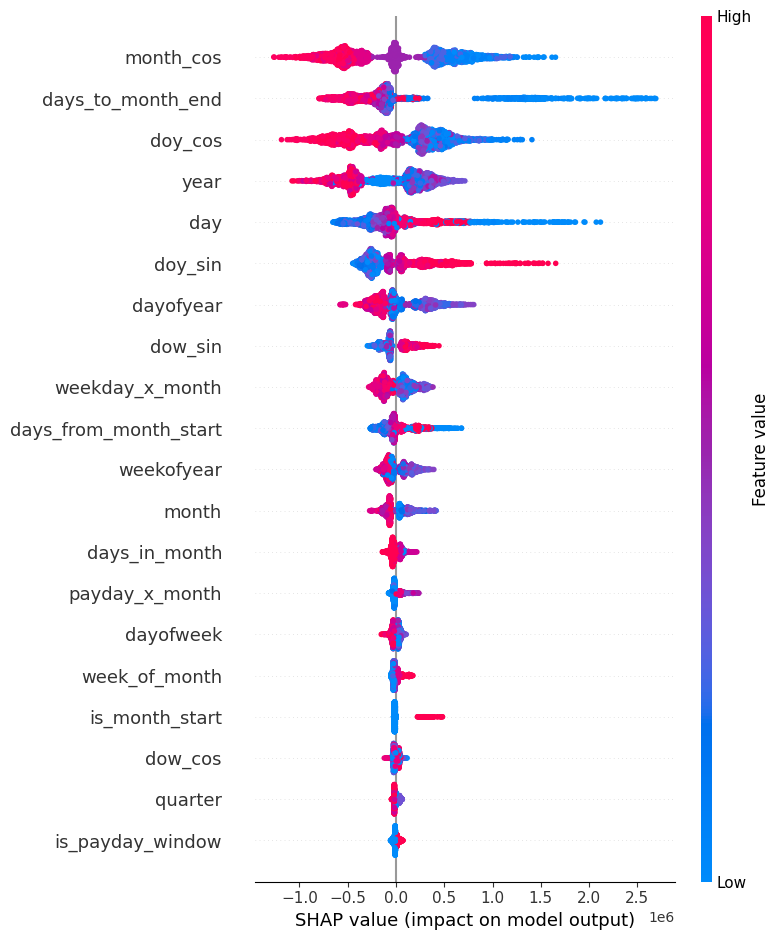

In [47]:
shap.summary_plot(shap_values_revenue, X_sample)


**Nhận xét:**

- **Quan sát:**
  - **Tầm quan trọng của tính chu kỳ (Cyclical Features):** Các đặc trưng mang định dạng chu kỳ thời gian như `month_cos`, `doy_cos` (ngày trong năm), và `doy_sin` thống trị top đầu biểu đồ. Chúng tạo ra sự phân tách SHAP value rất rõ nét dọc theo trục 0 giữa hai dải màu đỏ (giá trị cao) và xanh dương (giá trị thấp).
  - **Hiệu ứng cuối tháng (End-of-month effect):** Biến `days_to_month_end` đặc biệt gây chú ý với một dải màu xanh dương (số ngày còn lại ít, tức là các ngày sát cuối tháng) vươn một chiếc đuôi (long tail) cực dài về phía bên phải. Lượng SHAP value tại vùng này đạt mức cực đại (hơn 2.5 - 3.5 triệu), lớn nhất trong tất cả các đặc trưng.
  - **Sự dịch chuyển theo Năm (Yearly Trend):** Ở đặc trưng `year`, các điểm màu đỏ (những năm gần đây) hầu hết có SHAP value âm (nằm bên trái trục tung), trong khi các điểm màu xanh (những năm quá khứ) lại co cụm ở vùng SHAP value dương.
  - **Sự mờ nhạt của các biến sự kiện:** Các biến đánh dấu (flags) sự kiện rời rạc như `is_back_to_school`, `is_month_start`, `is_payday_window` nằm bẹp ở nửa dưới biểu đồ. Mức phân tán SHAP value của chúng rất hẹp và xoay quanh mốc 0, cho thấy tác động biên (marginal impact) lên mô hình là rất thấp.

- **Insights:**
  - **Mô hình kinh doanh phụ thuộc nặng vào thời điểm "chốt sổ":** Đuôi SHAP khổng lồ của `days_to_month_end` phơi bày một đặc tính cốt lõi của doanh nghiệp: Doanh thu tăng đột biến vào những ngày cuối tháng. Điều này thường phản ánh áp lực "chạy KPI/chốt sales" của đội ngũ kinh doanh, hoặc chu kỳ xả ngân sách/nhập hàng dự trữ của mạng lưới đại lý (B2B). 
  - **Sự xói mòn doanh thu theo thời gian (Regime Shift/Non-stationarity):** Tác động âm của các năm gần đây (`year` cao) xác nhận lại sự thật từ lịch sử huấn luyện: Doanh nghiệp đang trải qua một giai đoạn thoái trào hoặc bước vào "bình thường mới" với mức nền doanh thu trung bình thấp hơn hẳn so với kỷ nguyên trước đó.
  - **Tính mùa vụ vượt trội so với hiệu ứng sự kiện:** Mô hình Tree-based (XGBoost/LightGBM) đã tìm thấy tín hiệu mạnh nhất từ các hàm lượng giác tuần hoàn (sine/cosine của thời gian) để bắt nhịp độ kinh doanh, thay vì sử dụng các cờ đánh dấu lễ hội/sự kiện. Các sự kiện đơn lẻ hiện tại không đủ sức nặng hoặc bị nhịp đập của "cuối tháng/cuối năm" lấn át hoàn toàn.

- **Gợi ý hành động:**
  - **Tối ưu hóa nguồn lực theo "Điểm rơi doanh thu":** Cần dồn trọng tâm ngân sách Marketing, lực lượng Telesales và chuẩn bị sẵn sàng chuỗi cung ứng (Logistics/Kho bãi) vào cửa sổ 3-5 ngày cuối tháng để tối đa hóa lượng đơn hàng bùng nổ tự nhiên. Tránh rải đều ngân sách quảng cáo một cách lãng phí vào giữa tháng (khi biến `days_to_month_end` không tạo ra SHAP value đột biến).
  - **Xử lý hiện tượng Non-stationarity cho dự báo tương lai:** Việc giữ biến `year` dạng tuyến tính có rủi ro rất cao khi dự báo out-of-sample (mô hình có thể extrapolate đà giảm này xuống mức cực đoan). Bắt buộc phải áp dụng kỹ thuật Trọng số suy giảm theo thời gian (Time-decay weights / Sample weights) để mô hình "quên" bớt mức doanh thu cao phi thực tế của tệp dữ liệu cũ (2012-2016), giúp thuật toán hội tụ tốt hơn vào cấu trúc dữ liệu của hiện tại.
  - **Tái cấu trúc các biến Sự kiện (Feature Engineering):** Vì các biến như `is_payday_window` hay `is_back_to_school` đang hoạt động kém hiệu quả, hãy nâng cấp chúng thành các biến Tương tác (Interaction Features) sâu hơn. Ví dụ: "Giao thoa giữa Cuối tháng và Lễ Tết" hoặc "Số ngày đếm ngược đến sự kiện" thay vì chỉ dùng binary flags, qua đó cung cấp cho mô hình một bối cảnh nhân quả mạnh mẽ hơn để giải thích nhu cầu.